# 02 - Exploratory Data Analysis

Explores the tables produced by `data_preprocessing.ipynb` (`Data/processed/`) to surface the revenue, customer, restaurant, and delivery patterns the README's Business Intelligence and data-mining sections call for. Every chart uses one consistent, colorblind-validated palette (single sequential blue for magnitude comparisons, since nearly every chart here is "how big is each category," not "tell these series apart").

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

PROCESSED = Path("../Data/processed")

# Dataviz palette (validated: see project's dataviz skill / references/palette.md)
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"
SEQ_SINGLE = "#2a78d6"  # sequential blue - default for magnitude comparisons

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_SECONDARY,
        "axes.grid": True,
        "grid.color": GRIDLINE,
        "grid.linewidth": 0.8,
        "text.color": INK_PRIMARY,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "figure.dpi": 110,
    }
)


def style_hbar(ax):
    """Horizontal bar: keep the value-axis grid, drop the category-axis grid.

    Sort data ascending before plotting so the largest bar lands at the top
    (matplotlib draws the first category at the bottom by default).
    """
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.6)


def style_vbar(ax):
    """Vertical bar: keep the value-axis grid, drop the category-axis grid."""
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", alpha=0.6)


users = pd.read_csv(PROCESSED / "users_clean.csv")
restaurants = pd.read_csv(PROCESSED / "restaurants_clean.csv")
food = pd.read_csv(PROCESSED / "food_clean.csv")
menu = pd.read_csv(PROCESSED / "menu_clean.csv")
orders = pd.read_csv(PROCESSED / "orders_clean.csv", parse_dates=["order_date"])
customer_features = pd.read_csv(
    PROCESSED / "customer_features.csv",
    parse_dates=["first_order_date", "last_order_date"],
)
order_history = pd.read_csv(
    PROCESSED / "order_history_clean.csv", parse_dates=["order_placed_at"]
)
delivery_ops = pd.read_csv(PROCESSED / "delivery_ops_clean.csv", parse_dates=["order_date"])

print("users", users.shape)
print("restaurants", restaurants.shape)
print("food", food.shape)
print("menu", menu.shape)
print("orders", orders.shape)
print("customer_features", customer_features.shape)
print("order_history", order_history.shape)
print("delivery_ops", delivery_ops.shape)

users (100000, 10)
restaurants (148455, 8)
food (371560, 3)
menu (1178743, 5)
orders (146979, 6)
customer_features (77223, 14)
order_history (21321, 29)
delivery_ops (45584, 20)


## 1. Revenue & Order Trends

Monthly revenue and monthly order volume from `orders_clean`, plotted as two separate single-series line charts (never combined on a dual axis - they're different units).

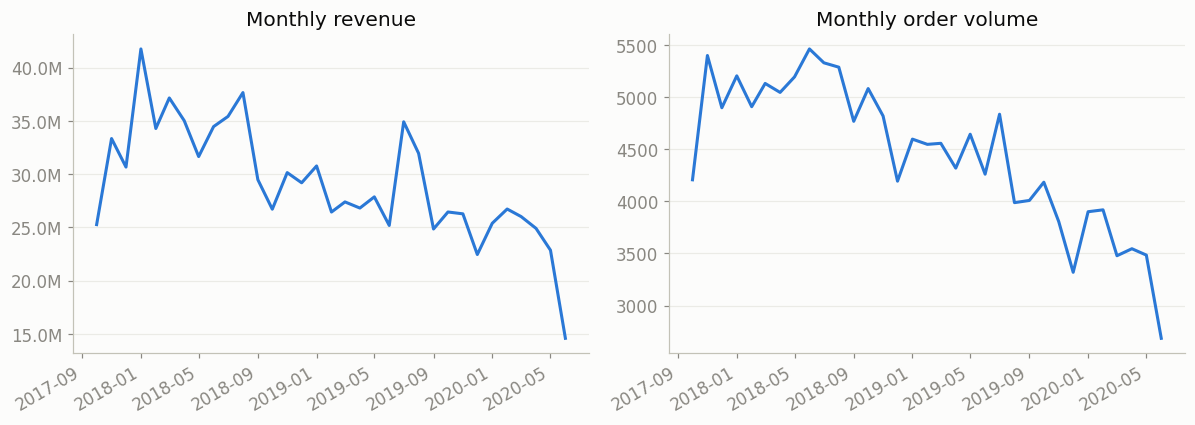

In [2]:
monthly = orders.set_index("order_date").resample("MS").agg(
    revenue=("sales_amount", "sum"), order_count=("sales_amount", "size")
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(monthly.index, monthly["revenue"], color=SEQ_SINGLE, linewidth=2)
axes[0].set_title("Monthly revenue")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
style_vbar(axes[0])

axes[1].plot(monthly.index, monthly["order_count"], color=SEQ_SINGLE, linewidth=2)
axes[1].set_title("Monthly order volume")
style_vbar(axes[1])

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 2. Customer Spending & Recency

Distributions from `customer_features` - the same features the K-Means segmentation step will cluster on. Both are heavily right-skewed, which is expected for spend/recency data and worth keeping in mind when scaling features for clustering.

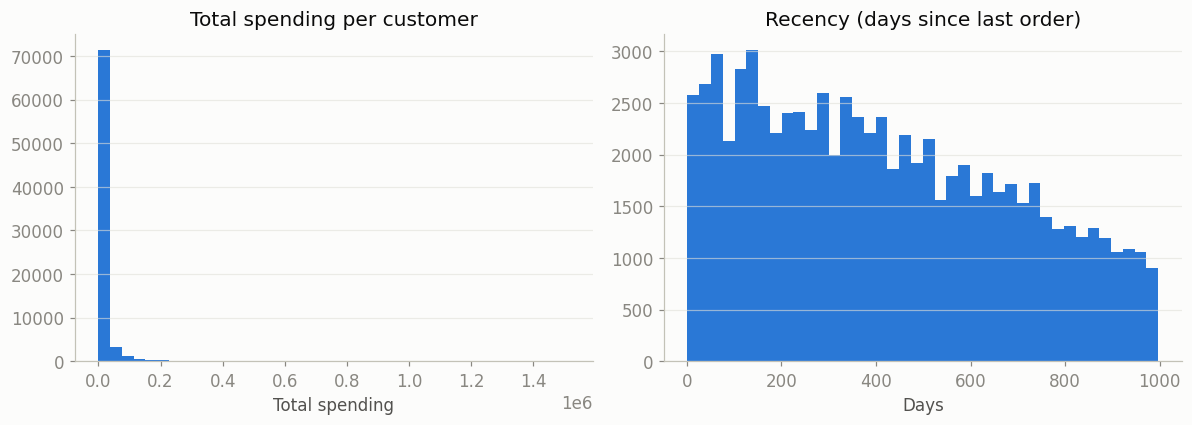

       total_orders  total_spending  avg_order_value  recency_days
count  77223.000000    7.722300e+04     7.722300e+04  77223.000000
mean       1.903306    1.248134e+04     6.476053e+03    419.687956
std        1.028239    4.176632e+04     2.291688e+04    272.516551
min        1.000000    5.000000e+00     5.000000e+00      1.000000
25%        1.000000    4.220000e+02     2.845000e+02    186.000000
50%        2.000000    1.921000e+03     1.067000e+03    387.000000
75%        2.000000    8.843000e+03     4.420500e+03    635.000000
max        8.000000    1.514634e+06     1.338264e+06    997.000000


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(customer_features["total_spending"], bins=40, color=SEQ_SINGLE)
axes[0].set_title("Total spending per customer")
axes[0].set_xlabel("Total spending")
style_vbar(axes[0])

axes[1].hist(customer_features["recency_days"], bins=40, color=SEQ_SINGLE)
axes[1].set_title("Recency (days since last order)")
axes[1].set_xlabel("Days")
style_vbar(axes[1])

fig.tight_layout()
plt.show()

print(customer_features[["total_orders", "total_spending", "avg_order_value", "recency_days"]].describe())

## 3. Spending by Demographic

Average spend per customer by monthly-income bracket (kept in its natural low->high order) and by gender.

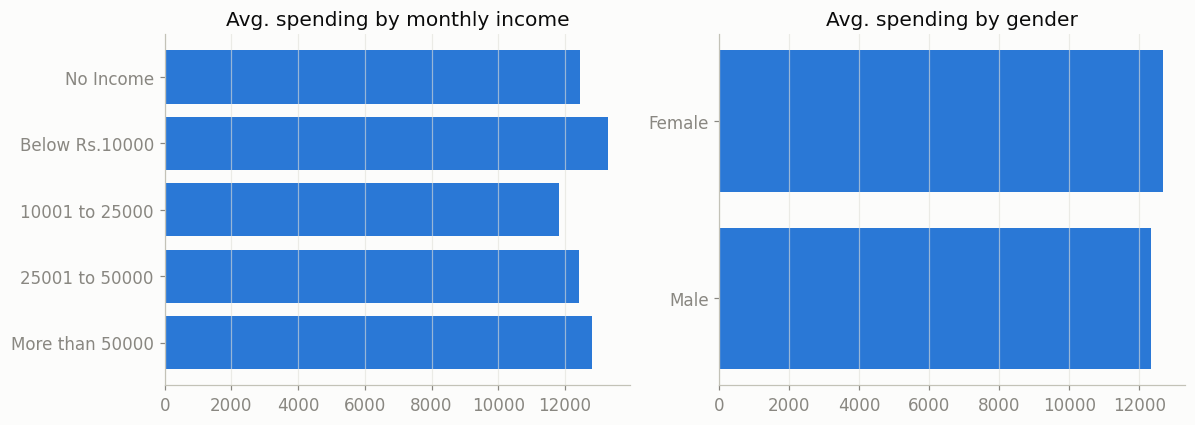

In [4]:
income_order = ["No Income", "Below Rs.10000", "10001 to 25000", "25001 to 50000", "More than 50000"]
by_income = (
    customer_features.groupby("monthly_income")["total_spending"]
    .mean()
    .reindex(income_order)
)
by_gender = customer_features.groupby("gender")["total_spending"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].barh(by_income.index, by_income.values, color=SEQ_SINGLE)
axes[0].set_title("Avg. spending by monthly income")
style_hbar(axes[0])
axes[0].invert_yaxis()  # show brackets top-to-bottom in their natural low -> high order

axes[1].barh(by_gender.index, by_gender.values, color=SEQ_SINGLE)
axes[1].set_title("Avg. spending by gender")
style_hbar(axes[1])  # already sorted ascending, so the highest spender lands on top

fig.tight_layout()
plt.show()

## 4. Top Restaurants by Revenue

Joins `orders_clean` to `restaurants_clean` to rank restaurants by total sales.

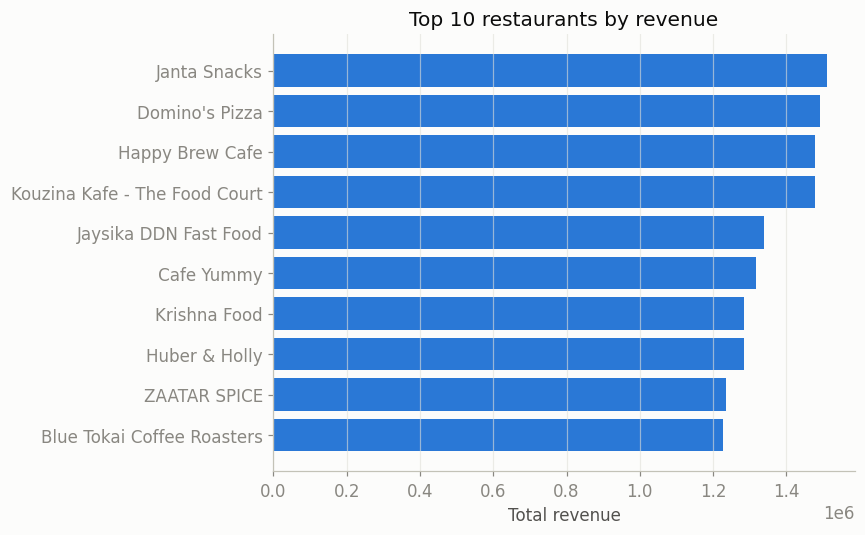

In [5]:
revenue_by_restaurant = (
    orders.groupby("r_id")["sales_amount"]
    .sum()
    .rename("revenue")
    .reset_index()
    .merge(restaurants[["r_id", "name", "city"]], on="r_id", how="left")
)

top_restaurants = revenue_by_restaurant.nlargest(10, "revenue").sort_values("revenue")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_restaurants["name"], top_restaurants["revenue"], color=SEQ_SINGLE)
ax.set_title("Top 10 restaurants by revenue")
ax.set_xlabel("Total revenue")
style_hbar(ax)
fig.tight_layout()
plt.show()

## 5. Cuisine Popularity & Restaurant Quality

`restaurants_clean.cuisine` holds a comma-separated list per restaurant (e.g. `"Beverages,Pizzas"`) - split and explode it to count restaurants per cuisine. Alongside that, the rating and cost distributions across all restaurants.

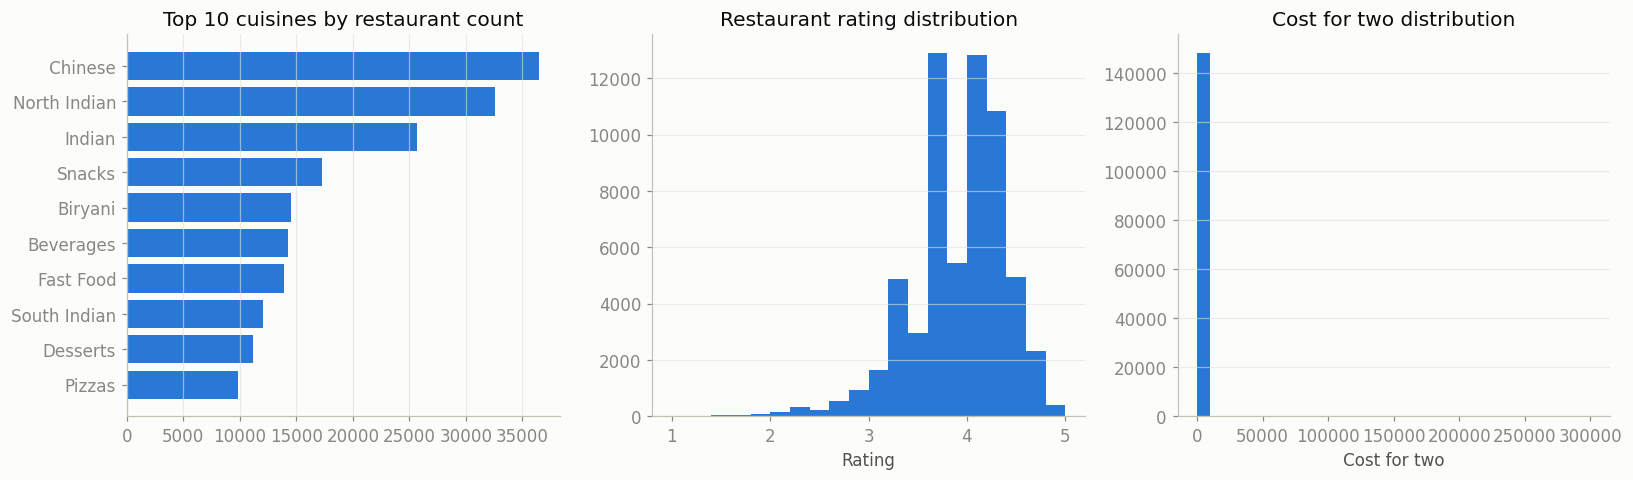

In [6]:
cuisine_counts = (
    restaurants["cuisine"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
    .sort_values()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].barh(cuisine_counts.index, cuisine_counts.values, color=SEQ_SINGLE)
axes[0].set_title("Top 10 cuisines by restaurant count")
style_hbar(axes[0])

axes[1].hist(restaurants["rating"].dropna(), bins=20, color=SEQ_SINGLE)
axes[1].set_title("Restaurant rating distribution")
axes[1].set_xlabel("Rating")
style_vbar(axes[1])

axes[2].hist(restaurants["cost_for_two"].dropna(), bins=30, color=SEQ_SINGLE)
axes[2].set_title("Cost for two distribution")
axes[2].set_xlabel("Cost for two")
style_vbar(axes[2])

fig.tight_layout()
plt.show()

## 6. Order Outcomes & Ratings

From `order_history_clean`: how orders resolve (`order_status`) and how they're rated when a rating is left.

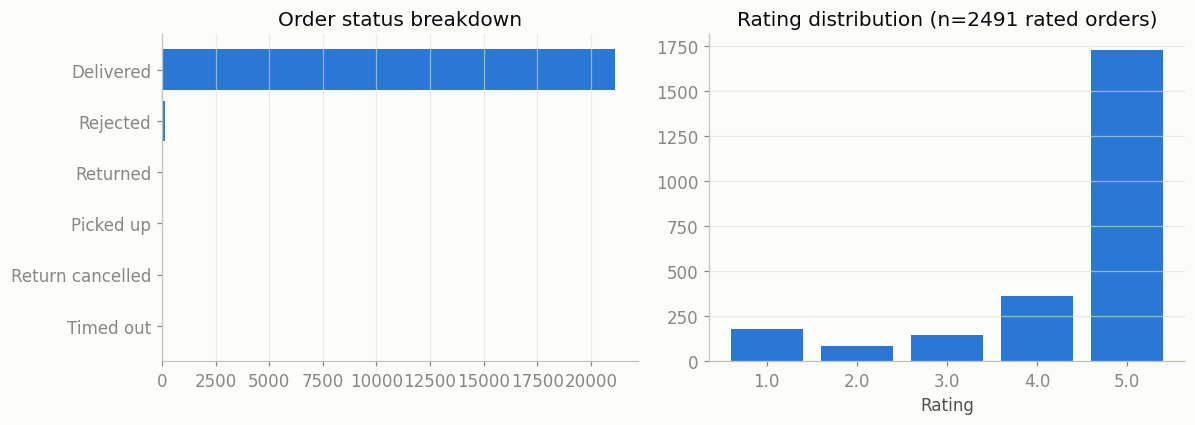

In [7]:
status_counts = order_history["order_status"].value_counts().sort_values()
rating_counts = order_history["rating"].dropna().value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].barh(status_counts.index, status_counts.values, color=SEQ_SINGLE)
axes[0].set_title("Order status breakdown")
style_hbar(axes[0])

axes[1].bar(rating_counts.index.astype(str), rating_counts.values, color=SEQ_SINGLE)
axes[1].set_title(f"Rating distribution (n={int(rating_counts.sum())} rated orders)")
axes[1].set_xlabel("Rating")
style_vbar(axes[1])

fig.tight_layout()
plt.show()

## 7. Most Ordered Items (Market Basket Preview)

Re-parses the `items_in_order` free text (e.g. `"1 x Grilled Chicken Jamaican Tender, ..."`) into individual line items to see what's ordered most often - a preview of the basket data the Apriori market-basket-analysis notebook will mine for association rules.

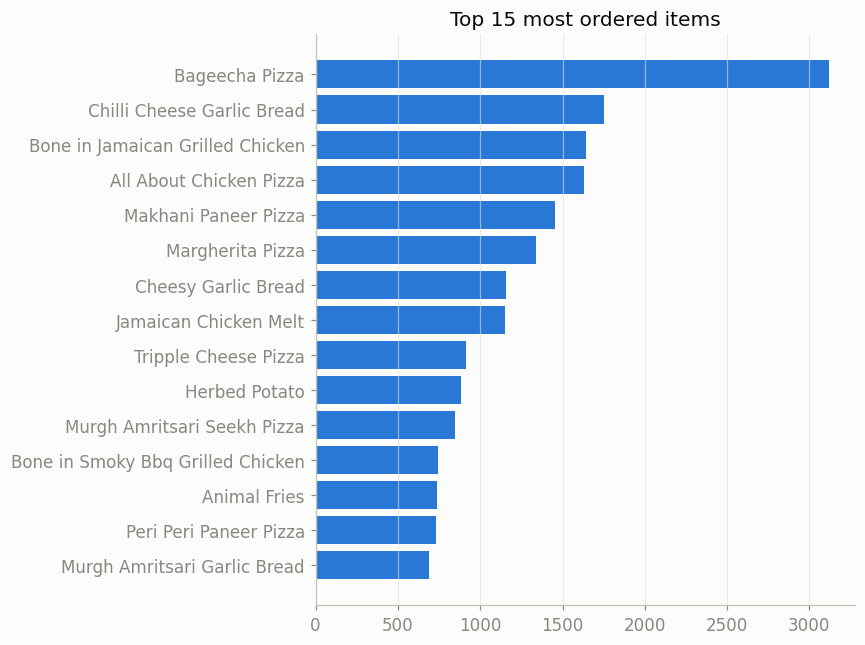

In [8]:
def extract_items(text):
    return [
        m.group(1).strip()
        for part in str(text).split(",")
        if (m := re.match(r"\s*\d+\s*x\s*(.+)", part.strip()))
    ]


item_counts = (
    order_history["items_in_order"]
    .apply(extract_items)
    .explode()
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(item_counts.index, item_counts.values, color=SEQ_SINGLE)
ax.set_title("Top 15 most ordered items")
style_hbar(ax)
fig.tight_layout()
plt.show()

## 8. Delivery Performance

From `delivery_ops_clean`: average delivery time by weather, traffic density, vehicle type, and festival day - the factors most likely to explain delivery-time variance.

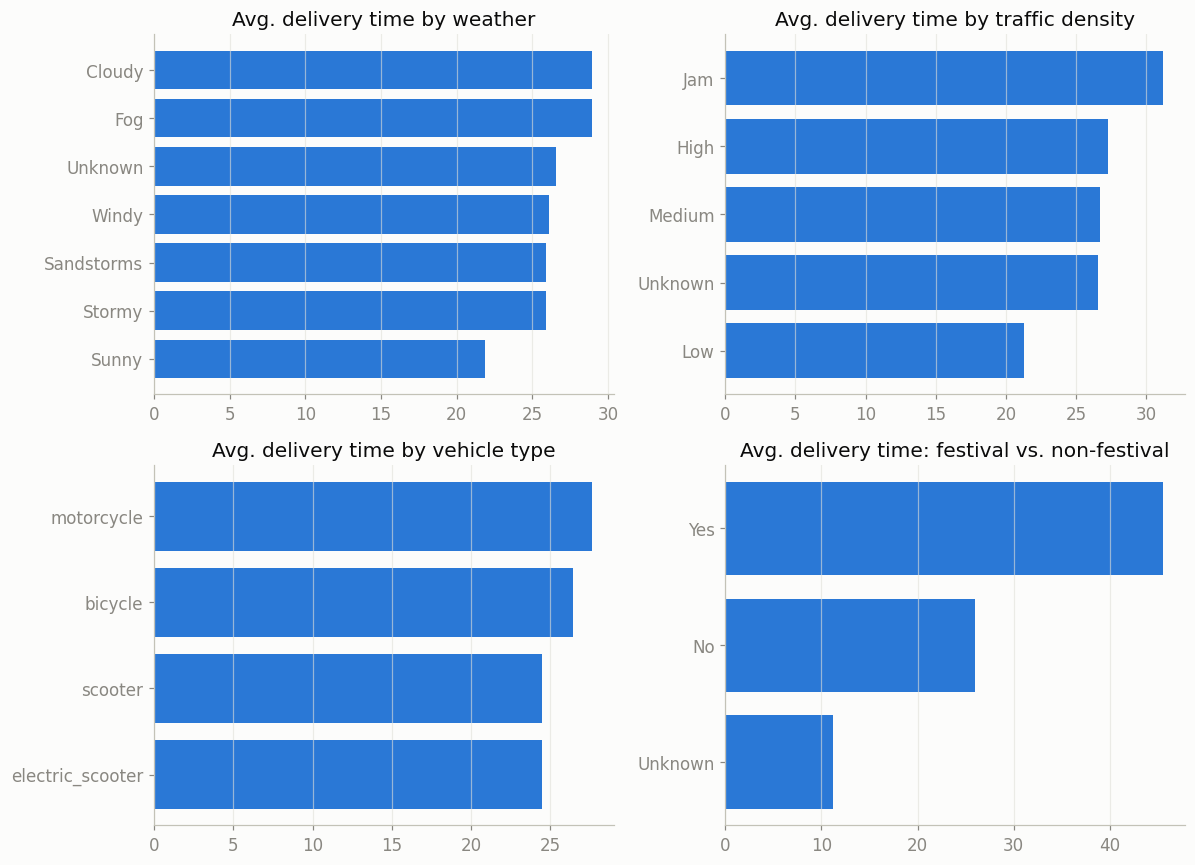

In [9]:
by_weather = delivery_ops.groupby("weather_conditions")["time_taken_min"].mean().sort_values()
by_traffic = delivery_ops.groupby("road_traffic_density")["time_taken_min"].mean().sort_values()
by_vehicle = delivery_ops.groupby("type_of_vehicle")["time_taken_min"].mean().sort_values()
by_festival = delivery_ops.groupby("festival")["time_taken_min"].mean().sort_values()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].barh(by_weather.index, by_weather.values, color=SEQ_SINGLE)
axes[0, 0].set_title("Avg. delivery time by weather")
style_hbar(axes[0, 0])

axes[0, 1].barh(by_traffic.index, by_traffic.values, color=SEQ_SINGLE)
axes[0, 1].set_title("Avg. delivery time by traffic density")
style_hbar(axes[0, 1])

axes[1, 0].barh(by_vehicle.index, by_vehicle.values, color=SEQ_SINGLE)
axes[1, 0].set_title("Avg. delivery time by vehicle type")
style_hbar(axes[1, 0])

axes[1, 1].barh(by_festival.index, by_festival.values, color=SEQ_SINGLE)
axes[1, 1].set_title("Avg. delivery time: festival vs. non-festival")
style_hbar(axes[1, 1])

fig.tight_layout()
plt.show()

## Summary

Key patterns to carry into the next steps:

- **Customer spending and recency are both right-skewed** - scale/transform (e.g. log or `StandardScaler`) before K-Means clustering in `customer_segmentation.ipynb`.
- **Revenue and order volume trends** give the BI dashboard's headline time series.
- **A small set of restaurants and cuisines dominate revenue/count** - worth a "top N + Other" treatment on the dashboard rather than listing every restaurant.
- **The parsed `items_in_order` basket** is ready to feed `mlxtend`'s `apriori`/`association_rules` in the market-basket-analysis notebook.
- **Traffic density and weather show the clearest spread in delivery time** - the strongest candidate features for a delivery-time model, if one is added later.

Next: `customer_segmentation.ipynb` (K-Means on `customer_features.csv`).